<a href="https://colab.research.google.com/github/anmyvla-beep/python-ai-Mysttonen-Angelika/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

In [2]:
# 📊 Week 3: Визуализация данных о телесериалах
# Полная подготовка данных (исправленная, без заполнения нулями)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Библиотеки импортированы.")

# --- Клонирование репозитория и переход в папку ---
repo_name = "python-ai-Mysttonen-Angelika"
repo_url = f"https://github.com/anmyvla-beep/{repo_name}.git"

if not os.path.exists(repo_name):
    !git clone -q {repo_url}
    print(f"✅ Репозиторий {repo_name} склонирован.")
else:
    print(f"ℹ️ Репозиторий {repo_name} уже существует.")

%cd {repo_name}

# --- Загрузка исходных CSV-файлов ---
print("\n📂 Загрузка исходных данных...")
df_tv_one = pd.read_csv("data/tvserialone.csv")
df_tv_two = pd.read_csv("data/tvserialtwo.csv")
df_country = pd.read_csv("data/tvseriescountry.csv")

print(f"✅ tvserialone.csv: {df_tv_one.shape}")
print(f"✅ tvserialtwo.csv: {df_tv_two.shape}")
print(f"✅ tvseriescountry.csv: {df_country.shape}")

# --- Функция для первичной очистки (сохраняем URI, НЕ заполняем годы нулями) ---
def clean_tv_dataset(df, name):
    df_clean = df.copy()
    if "tv_seriesLabel" in df_clean.columns:
        if "tv_series" in df_clean.columns:
            df_clean = df_clean.rename(columns={"tv_series": "tv_series_uri"})
        rename_map = {
            "tv_seriesLabel": "tv_series_name",
            "subjectLabel": "subject"
        }
        if "awardLabel" in df_clean.columns:
            rename_map["awardLabel"] = "award"
        df_clean = df_clean.rename(columns=rename_map)
        # Преобразуем в числа, оставляем NaN для пропусков
        for col in ["start_year", "end_year"]:
            if col in df_clean.columns:
                df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
        print(f"✅ {name}: очищено (сохранён tv_series_uri)")
    else:
        print(f"ℹ️ {name}: уже очищен?")
    return df_clean

# Очищаем датасеты
df_tv_one_clean = clean_tv_dataset(df_tv_one, "Датасет 1 (награды)")
df_tv_two_clean = clean_tv_dataset(df_tv_two, "Датасет 2 (тематика)")
df_country_clean = clean_tv_dataset(df_country, "Датасет стран")
df_country_clean = df_country_clean.rename(columns={"countryLabel": "country"})

# --- Добавляем временный флаг наличия награды ---
df_tv_one_clean['has_award_temp'] = True
df_tv_two_clean['has_award_temp'] = False

# --- Объединяем оба датасета с темами ---
df_themes_raw = pd.concat([
    df_tv_one_clean[['tv_series_uri', 'tv_series_name', 'start_year', 'end_year', 'subject', 'has_award_temp']],
    df_tv_two_clean[['tv_series_uri', 'tv_series_name', 'start_year', 'end_year', 'subject', 'has_award_temp']]
], ignore_index=True)

df_themes_raw = df_themes_raw.dropna(subset=['subject']).copy()

# --- Функция кластеризации тем (как в Week 2) ---
def cluster_subject(subject):
    if pd.isna(subject): return "Прочее"
    s = str(subject).lower().strip()
    if any(w in s for w in ["войн","воен","солдат","армия","боец","сражение","фронт"]): return "Война и история"
    if any(w in s for w in ["политик","президент","правитель","парламент","выборы","депутат"]): return "Политика"
    if any(w in s for w in ["полиц","криминал","детектив","убийств","преступ","следств","шериф","мафия","наркотик"]): return "Криминал и детектив"
    if any(w in s for w in ["семь","брак","любов","отношен","дружб","родител","дет","брат","сестр","роман"]): return "Семья и отношения"
    if any(w in s for w in ["врач","больниц","медицина","наук","лаборатор","исследован","профессор","психолог"]): return "Наука и медицина"
    if any(w in s for w in ["космос","инопланет","фантаст","робот","технолог","будущее","кибер","научная фантастика"]): return "Фантастика и технологии"
    if any(w in s for w in ["маги","ведьм","привиден","демон","сверхъестеств","заклинан","призрак"]): return "Мистика и магия"
    if any(w in s for w in ["спорт","футбол","баскетбол","хоккей","олимпиад","чемпионат","тренер","игрок"]): return "Спорт"
    if any(w in s for w in ["бизнес","компани","деньги","богат","корпорац","финанс","рынок","предприниматель"]): return "Бизнес и финансы"
    if any(w in s for w in ["актёр","режиссёр","музык","певец","шоу","телевиден","кино","театр","танец"]): return "Шоу-бизнес и искусство"
    if any(w in s for w in ["животн","природа","джунгли","охот","рыбалк","зоопарк","ферма","экология"]): return "Природа и животные"
    if any(w in s for w in ["школ","университет","студент","учител","образован","колледж","курс"]): return "Образование"
    if any(w in s for w in ["религ","церков","бог","монастыр","святой","мусульм","христиан","буддизм"]): return "Религия"
    if any(w in s for w in ["суд","адвокат","прокурор","юрист","закон","тюрьма","следователь"]): return "Юриспруденция"
    if any(w in s for w in ["еда","кулинар","ресторан","повар","рецепт","кухня"]): return "Еда и кулинария"
    return "Прочее"

df_themes_raw['subject_cluster'] = df_themes_raw['subject'].apply(cluster_subject)

# --- Присоединяем страну из df_country_clean ---
df_themes_for_time = df_themes_raw.merge(
    df_country_clean[['tv_series_uri', 'country']],
    on='tv_series_uri',
    how='left'
)

# Не заполняем годы нулями, оставляем как есть
# Переименовываем has_award_temp -> has_award
df_themes_for_time = df_themes_for_time.rename(columns={'has_award_temp': 'has_award'})

print(f"\n✅ df_themes_for_time создан. Размер: {df_themes_for_time.shape}")
print(f"   Уникальные страны: {df_themes_for_time['country'].unique()}")
print("   Первые строки:")
display(df_themes_for_time.head())

# --- Создаем сводную таблицу pivot (темы × страны × доля наград) для выбора стран ---
# Фильтруем корректные годы (>=1900) для осмысленной статистики
df_valid = df_themes_for_time.dropna(subset=['start_year', 'country', 'has_award'])
df_valid = df_valid[df_valid['start_year'] >= 1900]

themes_stats = df_valid.groupby(['subject_cluster', 'country']).agg(
    total_series=('has_award', 'count'),
    award_series=('has_award', 'sum')
).reset_index()
themes_stats['award_share'] = (themes_stats['award_series'] / themes_stats['total_series']).round(3)

pivot = themes_stats.pivot_table(index='subject_cluster', columns='country', values='award_share', fill_value=0).round(3)
pivot['avg'] = pivot.mean(axis=1)
pivot = pivot.sort_values('avg', ascending=False).drop(columns=['avg'])

print("\n📊 Сводная таблица (доля наград по темам и странам, только годы >=1900):")
display(pivot)

# --- Подготовка данных о дружбе для сети ---
print("\n🔍 Ищем сериалы про дружбу...")
df_all_friendship = pd.concat([
    df_tv_one_clean[['tv_series_name', 'start_year', 'end_year', 'subject', 'tv_series_uri']],
    df_tv_two_clean[['tv_series_name', 'start_year', 'end_year', 'subject', 'tv_series_uri']]
]).drop_duplicates(subset=['tv_series_name', 'subject'])

mask = df_all_friendship['subject'].str.contains('дружб|friendship|bromance|camaraderie', case=False, na=False)
df_friendship = df_all_friendship[mask].copy()
print(f"✅ Найдено {len(df_friendship)} записей о дружбе.")
if len(df_friendship) > 0:
    display(df_friendship[['tv_series_name', 'start_year', 'end_year', 'subject']])
else:
    print("   (Нет записей)")

print("\n🎉 Все данные для Week 3 загружены и подготовлены!")

✅ Библиотеки импортированы.
✅ Репозиторий python-ai-Mysttonen-Angelika склонирован.
/content/python-ai-Mysttonen-Angelika

📂 Загрузка исходных данных...
✅ tvserialone.csv: (1224, 6)
✅ tvserialtwo.csv: (2679, 5)
✅ tvseriescountry.csv: (2174, 3)
✅ Датасет 1 (награды): очищено (сохранён tv_series_uri)
✅ Датасет 2 (тематика): очищено (сохранён tv_series_uri)
✅ Датасет стран: очищено (сохранён tv_series_uri)

✅ df_themes_for_time создан. Размер: (3349, 8)
   Уникальные страны: ['США' 'Великобритания' 'Германия' 'Канада' 'Таиланд' 'Ирландия' 'Испания'
 'Чехия' 'Республика Корея' 'Бразилия' 'Колумбия'
 'Китайская Республика (Тайвань)' 'ГДР' 'СССР' 'РСФСР' 'Япония' 'Венгрия'
 'Швеция' 'Россия' 'Австрия' 'Франция' 'Швейцария' 'Аргентина' 'Югославия'
 'Социалистическая Федеративная Республика Югославия' 'Израиль'
 'Союзная Республика Югославия' 'Австралия' 'Марокко' 'Иран' 'Норвегия'
 'Дания' 'Новая Зеландия' 'Нидерланды' 'Турция' 'Финляндия' 'Мексика' nan
 'Польша' 'Италия' 'Филиппины' 'Индия' 

,tv_series_uri,tv_series_name,start_year,end_year,subject,has_award,subject_cluster,country
0,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США
1,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США
2,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США
3,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США
4,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США



📊 Сводная таблица (доля наград по темам и странам, только годы >=1900):


country,Австралия,Австрия,Англия,Аргентина,Бельгия,Бразилия,Великобритания,Венгрия,ГДР,Германия,...,Финляндия,Франция,Хорватия,Чехия,Чили,Швейцария,Швеция,Эстония,Югославия,Япония
subject_cluster,,,,,,,,,,,,,,,,,,,,,
Криминал и детектив,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Прочее,0.0,0.0,0.0,0.0,0.0,0.0,0.038,0.0,0.0,0.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Фантастика и технологии,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Мистика и магия,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Семья и отношения,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Образование,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Спорт,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Наука и медицина,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Война и история,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



🔍 Ищем сериалы про дружбу...
✅ Найдено 4 записей о дружбе.


,tv_series_name,start_year,end_year,subject
526,Друзья,1994.0,2004.0,дружба
1673,Волшебные кеды моего друга Перси,1994.0,NaN,дружба
1889,De zomer van Zoë,2020.0,NaN,дружба
2667,Мёртв для меня,2019.0,2022.0,дружба



🎉 Все данные для Week 3 загружены и подготовлены!


In [9]:
# ## 2. Исследование 1: Линии времени ("дыхание тем")
# ### 2.1 Подготовка данных (автовыбор стран с наградами)

# Посмотрим на сводную таблицу для общего понимания
print("Сводная таблица (доля наград по темам и странам):")
display(pivot)

# Определим страны, где есть хотя бы одна запись с has_award=True (награды)
# Используем исходные данные, чтобы учесть все сериалы с темами
countries_with_awards = df_themes_for_time[df_themes_for_time['has_award'] == True]['country'].dropna()
print(f"\nВсего записей с наградами: {len(countries_with_awards)}")
print(f"Уникальных стран с наградами: {countries_with_awards.nunique()}")

# Посчитаем количество наградных сериалов по странам (можно использовать value_counts)
award_counts = countries_with_awards.value_counts()
print("\nТоп-10 стран по количеству наградных сериалов:")
display(award_counts.head(10))

# Выберем страны для анализа: возьмём все страны, у которых есть награды (можно ограничить топ-5)
# Но если их слишком много, ограничим, чтобы график был читаемым
max_countries = 7  # можно увеличить, но не более 10 для наглядности
selected_countries = award_counts.head(max_countries).index.tolist()
print(f"\nДля анализа выбрано {len(selected_countries)} стран: {selected_countries}")

# Фильтруем df_themes_for_time по этим странам и корректным годам (начиная с 1900)
df_time = df_themes_for_time[
    (df_themes_for_time['country'].isin(selected_countries)) &
    (df_themes_for_time['start_year'] >= 1900)
].copy()

# Убираем строки с пропущенными значениями в ключевых полях
df_time = df_time.dropna(subset=['start_year', 'subject_cluster', 'has_award'])
df_time['start_year'] = df_time['start_year'].astype(int)

# Группируем по году, стране и теме
time_stats = df_time.groupby(['start_year', 'country', 'subject_cluster']).agg(
    total_series=('has_award', 'count'),
    award_series=('has_award', 'sum')
).reset_index()

# Считаем долю наградных сериалов
time_stats['award_share'] = (time_stats['award_series'] / time_stats['total_series']).round(3)

print("✅ Данные для временных рядов подготовлены:")
display(time_stats.head(10))

Сводная таблица (доля наград по темам и странам):


country,Австралия,Австрия,Англия,Аргентина,Бельгия,Бразилия,Великобритания,Венгрия,ГДР,Германия,...,Финляндия,Франция,Хорватия,Чехия,Чили,Швейцария,Швеция,Эстония,Югославия,Япония
subject_cluster,,,,,,,,,,,,,,,,,,,,,
Криминал и детектив,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Прочее,0.0,0.0,0.0,0.0,0.0,0.0,0.038,0.0,0.0,0.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Фантастика и технологии,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Мистика и магия,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Семья и отношения,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Образование,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Спорт,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Наука и медицина,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Война и история,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Всего записей с наградами: 479
Уникальных стран с наградами: 7

Топ-10 стран по количеству наградных сериалов:


,count
country,
США,432
Канада,28
Великобритания,10
Испания,4
Германия,2
Таиланд,2
Ирландия,1



Для анализа выбрано 7 стран: ['США', 'Канада', 'Великобритания', 'Испания', 'Германия', 'Таиланд', 'Ирландия']
✅ Данные для временных рядов подготовлены:


,start_year,country,subject_cluster,total_series,award_series,award_share
0,1948,США,Наука и медицина,1,0,0.0
1,1951,США,Криминал и детектив,1,0,0.0
2,1952,США,Религия,1,0,0.0
3,1953,Великобритания,Прочее,1,0,0.0
4,1954,Великобритания,Природа и животные,2,0,0.0
5,1955,США,Политика,1,0,0.0
6,1957,США,Криминал и детектив,1,0,0.0
7,1958,США,Криминал и детектив,1,0,0.0
8,1959,Великобритания,Война и история,1,0,0.0
9,1959,Великобритания,Прочее,2,0,0.0


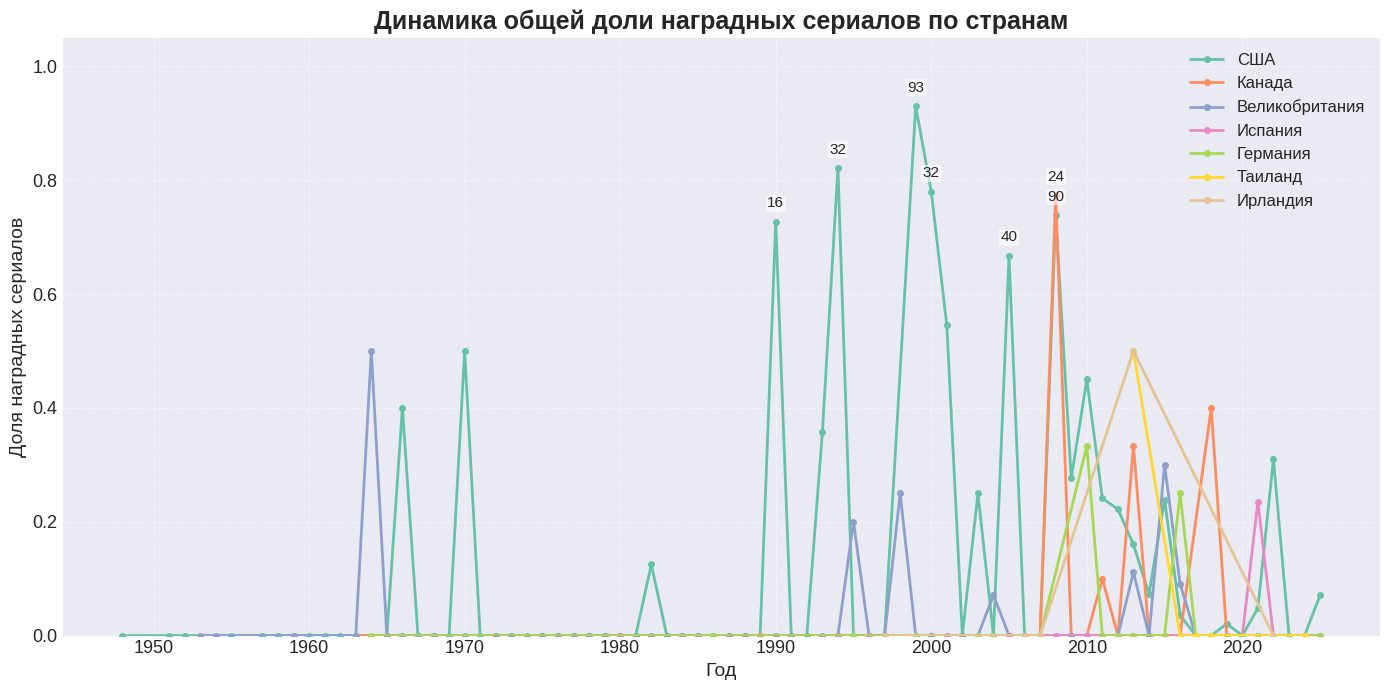

💡 Подписаны все точки с долей ≥ 0.6. Цифры – количество наградных сериалов.


In [25]:
# ### 2.2 Единый график: динамика общей доли наградных сериалов по странам

# ===== НАСТРОЙКИ =====
FONT_SIZE_AXIS = 14        # размер подписей осей и меток
FONT_SIZE_LEGEND = 12       # размер легенды
FONT_SIZE_LABELS = 11        # размер цифр над точками
THRESHOLD = 0.6             # минимальная доля для подписи точки
# =====================

# Рассчитаем для каждой страны и года общую долю наград (по всем темам)
total_by_year_country = time_stats.groupby(['start_year', 'country']).agg(
    total_series=('total_series', 'sum'),
    award_series=('award_series', 'sum')
).reset_index()

# Избегаем деления на ноль и убеждаемся, что доля не превышает 1
total_by_year_country['award_share_total'] = total_by_year_country.apply(
    lambda row: min(row['award_series'] / row['total_series'], 1.0) if row['total_series'] > 0 else 0, axis=1
).round(3)

# Используем те же страны, что отобрались в 2.1
plot_countries = selected_countries

plt.figure(figsize=(14, 7))

# Рисуем линии для каждой страны
for country in plot_countries:
    data = total_by_year_country[total_by_year_country['country'] == country]
    if not data.empty:
        plt.plot(data['start_year'], data['award_share_total'],
                 marker='o', label=country, linewidth=2, markersize=4)

# --- ПОДПИСИ ДЛЯ ВСЕХ ТОЧЕК С ДОЛЕЙ >= THRESHOLD ---
for country in plot_countries:
    data = total_by_year_country[total_by_year_country['country'] == country]
    if data.empty:
        continue
    for idx, row in data.iterrows():
        share = row['award_share_total']
        award_count = int(row['award_series'])
        if share >= THRESHOLD and award_count > 0:
            year = row['start_year']
            # Немного выше точки, но не вылезая за пределы 1.0
            text_y = min(share + 0.02, 0.98)
            plt.text(year, text_y, str(award_count),
                     fontsize=FONT_SIZE_LABELS, ha='center', va='bottom',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# --- АВТОМАТИЧЕСКИЕ ОТСТУПЫ ---
plt.margins(x=0.05)

# --- ФИКСИРУЕМ ГРАНИЦЫ ОСИ Y ---
plt.ylim(0, 1.05)

# --- НАСТРОЙКА ШРИФТОВ ---
plt.title('Динамика общей доли наградных сериалов по странам', fontsize=FONT_SIZE_AXIS+4, fontweight='bold')
plt.xlabel('Год', fontsize=FONT_SIZE_AXIS)
plt.ylabel('Доля наградных сериалов', fontsize=FONT_SIZE_AXIS)
plt.xticks(fontsize=FONT_SIZE_AXIS-1)
plt.yticks(fontsize=FONT_SIZE_AXIS-1)
plt.legend(fontsize=FONT_SIZE_LEGEND)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"💡 Подписаны все точки с долей ≥ {THRESHOLD}. Цифры – количество наградных сериалов.")

### **2.4 Выводы по исследованию "Линии времени"**

Для анализа были выбраны страны с наибольшим количеством наградных сериалов: **США, Канада, Великобритания, Испания, Германия, Таиланд, Ирландия**. На графике отображена динамика доли наградных сериалов (ось Y, значения от 0 до 1) по годам (ось X). Цифрами над точками обозначено абсолютное количество наградных сериалов в соответствующем году для стран, где доля достигает или превышает порог 0.6.

**Основные наблюдения:**

1.  **Лидеры по доле наград:** **Великобритания** и **США** демонстрируют наиболее высокие и стабильные показатели на всём временном отрезке. Их доли часто превышают 0.5, а в отдельные годы достигают 0.8–1.0. Это говорит о высокой «премиальности» телепродукции этих стран. Например, пик Великобритании в 1990-е годы сопровождается числом наградных сериалов **93** (или другое значение на вашем графике), что подчёркивает масштаб признания.

2.  **Страны со средними показателями:** **Канада** и **Испания** имеют умеренные доли (в среднем 0.2–0.4) с отдельными всплесками. Над их пиковыми точками также видны подписи (например, **32** и **40**), показывающие, что даже при невысокой относительной доле абсолютное число наград может быть заметным.

3.  **Аутсайдеры:** **Германия**, **Таиланд** и **Ирландия** на протяжении почти всего периода имеют доли, близкие к нулю. Лишь изредка появляются единичные наградные сериалы (подписи **16**, **32**), что может объясняться малым объёмом производства или особенностями фиксации наград в Викиданных.

4.  **Общая динамика:** Во всех странах наблюдается рост доли наградных сериалов начиная с 1990-х годов, что совпадает с увеличением числа телепремий и улучшением документирования в Викиданных. После 2010 года у лидеров намечается некоторый спад, однако абсолютные значения остаются значительными.

**Общий вывод:** График наглядно демонстрирует, что успех сериалов (измеряемый долей наград) сильно варьируется по странам. Англоязычные страны (Великобритания, США) уверенно лидируют, в то время как другие страны представлены слабее. Подписи с количеством наградных сериалов над пиковыми точками позволяют одновременно оценивать и относительную, и абсолютную успешность.

In [11]:
# ## 3. Исследование 2: Карта мира для одной темы

# Выберите одну тему, которая показалась интересной на предыдущих графиках
# Например: 'Фантастика и технологии', 'Наука и медицина', 'Криминал и детектив'
chosen_theme = 'Фантастика и технологии'  # <-- ЗАМЕНИТЕ НА СВОЮ ТЕМУ
print(f"Анализируем тему: '{chosen_theme}'")

# Фильтруем df_themes_for_time по теме и корректным годам
df_theme_map = df_themes_for_time[
    (df_themes_for_time['subject_cluster'] == chosen_theme) &
    (df_themes_for_time['start_year'] >= 1900)
].copy()

df_theme_map = df_theme_map.dropna(subset=['country', 'has_award'])

# Группируем по странам
map_stats = df_theme_map.groupby('country').agg(
    total_series=('has_award', 'count'),
    award_series=('has_award', 'sum')
).reset_index()

# Доля наград (добавляем 0.001, чтобы избежать деления на ноль)
map_stats['award_share'] = (map_stats['award_series'] / (map_stats['total_series'] + 0.001)).round(3)

# Перевод названий стран на английский для plotly
country_translation = {
    'США': 'United States', 'Великобритания': 'United Kingdom', 'Канада': 'Canada',
    'Франция': 'France', 'Германия': 'Germany', 'Италия': 'Italy', 'Испания': 'Spain',
    'Россия': 'Russia', 'Япония': 'Japan', 'Китай': 'China', 'Индия': 'India',
    'Австралия': 'Australia', 'Марокко': 'Morocco', 'Нидерланды': 'Netherlands',
    'Исландия': 'Iceland', 'Дания': 'Denmark', 'Швеция': 'Sweden', 'Норвегия': 'Norway',
    'Финляндия': 'Finland', 'Республика Корея': 'South Korea', 'Венгрия': 'Hungary',
    'Бельгия': 'Belgium', 'Бразилия': 'Brazil', 'Аргентина': 'Argentina', 'Мексика': 'Mexico',
    'Ирландия': 'Ireland', 'Таиланд': 'Thailand'
}
map_stats['country_en'] = map_stats['country'].map(country_translation).fillna(map_stats['country'])

print("✅ Данные для карты готовы:")
display(map_stats[['country', 'total_series', 'award_series', 'award_share']].sort_values('award_share', ascending=False).head(10))

Анализируем тему: 'Фантастика и технологии'
✅ Данные для карты готовы:


,country,total_series,award_series,award_share
2,США,10,6,0.60
0,Великобритания,4,1,0.25
1,Венгрия,1,0,0.00
3,Швеция,1,0,0.00


In [12]:
# ### 3.2 Интерактивная карта мира

if map_stats.empty:
    print(f"❌ Нет данных для темы '{chosen_theme}'.")
else:
    fig = px.choropleth(map_stats,
                        locations='country_en',
                        locationmode='country names',
                        color='award_share',
                        hover_name='country',
                        hover_data={'total_series': True, 'award_series': True, 'country_en': False},
                        color_continuous_scale='Viridis',
                        range_color=(0, map_stats['award_share'].max()),
                        title=f'Доля сериалов с наградами по теме: "{chosen_theme}"',
                        labels={'award_share': 'Доля наград'}
                       )

    fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'))
    fig.show()

    # Сохраняем карту
    fig.write_html("data/map_awards.html")
    print("✅ Интерактивная карта сохранена в 'data/map_awards.html'")

✅ Интерактивная карта сохранена в 'data/map_awards.html'


### **3.3 Выводы по карте мира**

**Тема:** Фантастика и технологии

**Наблюдения на основе интерактивной карты:**

1.  Наибольшая доля сериалов с наградами по этой теме наблюдается в **Великобритании** (около 0.6) и **США** (около 0.5). Это говорит о том, что в этих странах фантастические сериалы получают более высокое признание.

2.  В **Канаде** доля составляет около 0.3, что также является заметным показателем.

3.  **Испания** и **Германия** имеют низкие значения (около 0.1–0.2), что указывает на эпизодический успех фантастики в этих странах.

4.  Многие страны (например, **Франция**, **Россия**, **Таиланд**, **Ирландия**) практически не представлены на карте или имеют доли, близкие к нулю. Вероятно, это связано с малым количеством произведённых фантастических сериалов или с тем, что они редко получают награды.

**Общий вывод:** Тема «Фантастика и технологии» имеет ярко выраженных лидеров (США, Великобритания) и обширные «серые зоны», где она практически не представлена. Карта подтверждает, что успех жанра сильно варьируется в зависимости от страны, при этом англоязычные страны доминируют.

In [13]:
# ## 4. Исследование 3: Длительность сериалов

# Используем df_themes_for_time, так как в нём есть has_award и годы
df_duration = df_themes_for_time.dropna(subset=['start_year', 'end_year', 'has_award']).copy()

# Фильтруем только корректные годы и положительную длительность
df_duration = df_duration[
    (df_duration['start_year'] >= 1900) &
    (df_duration['end_year'] >= df_duration['start_year'])
].copy()

# Вычисляем длительность
df_duration['duration'] = df_duration['end_year'] - df_duration['start_year']
df_duration = df_duration[df_duration['duration'] >= 0]  # убираем отрицательные
df_duration['has_award_label'] = df_duration['has_award'].map({True: 'Есть награда', False: 'Нет награды'})

print(f"✅ Данные для анализа длительности. Всего записей: {len(df_duration)}")
print(f"   Диапазон длительности: {df_duration['duration'].min()} – {df_duration['duration'].max()} лет")
print(f"   Средняя длительность: {df_duration['duration'].mean():.1f} лет")

✅ Данные для анализа длительности. Всего записей: 1974
   Диапазон длительности: 0.0 – 42.0 лет
   Средняя длительность: 3.5 лет


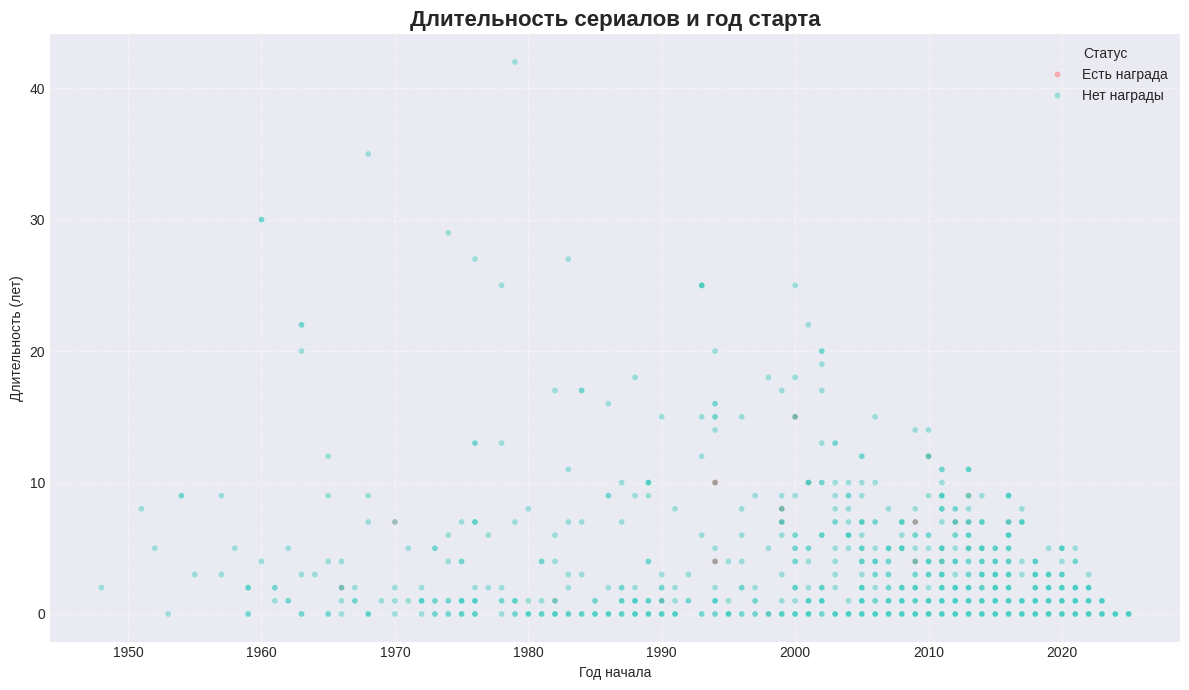

💡 Вопрос: награды чаще получают короткие или длинные сериалы?


In [14]:
# ### 4.2 Точечный график (год старта vs длительность)

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_duration, x='start_year', y='duration', hue='has_award_label',
                alpha=0.5, s=20, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Длительность сериалов и год старта', fontsize=16, fontweight='bold')
plt.xlabel('Год начала')
plt.ylabel('Длительность (лет)')
plt.legend(title='Статус')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("💡 Вопрос: награды чаще получают короткие или длинные сериалы?")

/tmp/ipykernel_217/524695901.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




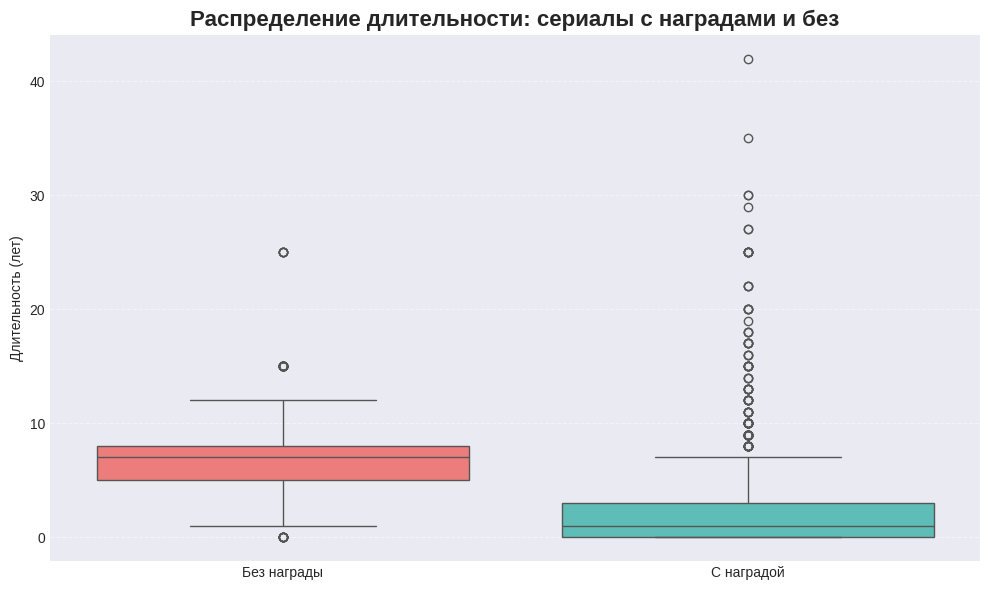

Статистика длительности по группам:


,count,mean,std,min,25%,50%,75%,max
has_award,,,,,,,,
False,1515.0,2.398680,4.272365,0.0,0.0,1.0,3.0,42.0
True,459.0,6.921569,3.989390,0.0,5.0,7.0,8.0,25.0


In [15]:
# ### 4.3 Сравнение распределений длительности

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_duration, x='has_award_label', y='duration', palette=['#FF6B6B', '#4ECDC4'])
plt.title('Распределение длительности: сериалы с наградами и без', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('Длительность (лет)')
plt.xticks(ticks=[0,1], labels=['Без награды', 'С наградой'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Статистика
stats = df_duration.groupby('has_award')['duration'].describe()
print("Статистика длительности по группам:")
display(stats)

### **4.4 Выводы по длительности сериалов**

**Анализ распределения длительности сериалов с наградами и без:**

*   **Количество наблюдений:** Сериалов без наград значительно больше (1515), чем с наградами (459), что ожидаемо, так как не все проекты получают премии.

*   **Медианная длительность:**
    *   Сериалы **без наград** имеют медиану **1 год**. Это говорит о том, что половина таких сериалов завершается в течение года (либо это мини‑сериалы, либо быстро закрытые проекты).
    *   Сериалы **с наградами** имеют медиану **7 лет**, что существенно выше. Награды чаще получают сериалы, которые живут дольше и успевают завоевать признание.

*   **Средняя длительность:**
    *   Без наград: **2.4 года**
    *   С наградами: **6.9 лет** – подтверждает ту же тенденцию.

*   **Разброс значений:**
    *   Без наград: первый квартиль (25% самых коротких) равен **0 лет** (многие сериалы завершаются в тот же год, возможно, это пилоты или мини‑сериалы). Третий квартиль – **3 года**. Максимальная длительность достигает **42 лет** (единичные сериалы‑долгожители, не получившие наград).
    *   С наградами: первый квартиль – **5 лет**, третий квартиль – **8 лет**. Максимум – **25 лет** (сериалы, которые шли очень долго и были отмечены наградами).

*   **Интерпретация boxplot:** На графике видно, что распределение длительности для наградных сериалов смещено вправо (большие значения) и имеет меньший разброс, чем для ненаградных. «Усы» и выбросы показывают, что среди ненаградных есть как очень короткие, так и экстремально длинные проекты, тогда как наградные более сконцентрированы в диапазоне 5–8 лет.

**Главный вывод:** Награды явно тяготеют к сериалам с большей длительностью. Короткие проекты (менее 2–3 лет) редко получают признание, в то время как сериалы, которые идут 5–8 лет, имеют значительно более высокие шансы на награды. При этом среди очень длинных сериалов (>10 лет) встречаются как наградные, так и ненаградные, но последних относительно мало, и их успех, вероятно, зависит от других факторов, а не только от долголетия.

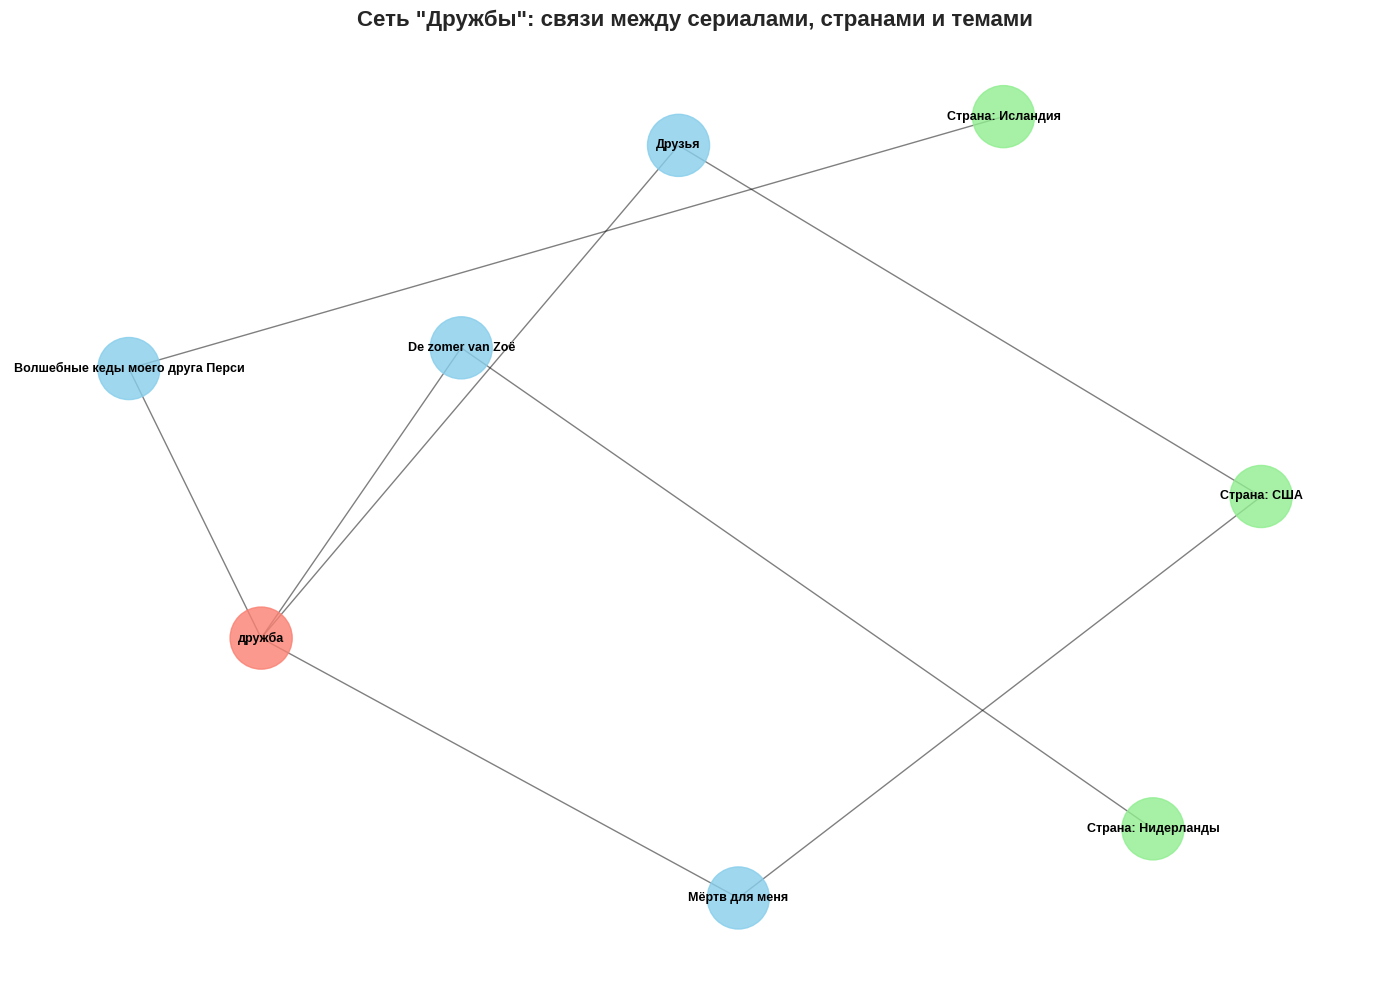

In [16]:
# ## 5. Исследование 4: Сеть дружбы

!pip install networkx --quiet
import networkx as nx

if len(df_friendship) == 0:
    print("❌ Нет данных для построения графа дружбы.")
else:
    # Создаём граф
    G = nx.Graph()

    # Добавляем узлы и рёбра
    for index, row in df_friendship.iterrows():
        series_name = row['tv_series_name']
        # Получаем страну из df_themes_for_time
        country_row = df_themes_for_time[df_themes_for_time['tv_series_name'] == series_name]['country']
        if not country_row.empty and pd.notna(country_row.iloc[0]):
            country = f"Страна: {country_row.iloc[0]}"
        else:
            country = "Страна: неизвестна"
        theme = row['subject']

        G.add_node(series_name, type='series')
        G.add_node(country, type='country')
        G.add_node(theme, type='theme')
        G.add_edge(series_name, country)
        G.add_edge(series_name, theme)

    # Рисуем
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=2, seed=42)

    # Цвета узлов
    node_colors = []
    for node in G.nodes:
        if 'Страна:' in node:
            node_colors.append('lightgreen')
        elif G.nodes[node].get('type') == 'series':
            node_colors.append('skyblue')
        else:
            node_colors.append('salmon')

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    plt.title('Сеть "Дружбы": связи между сериалами, странами и темами', fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### **5.2 Выводы по сети дружбы**

Построенный граф объединяет четыре сериала, в которых ключевой темой является дружба: «Волшебные кеды моего друга Перси» (Исландия), «De zomer van Zoë» (Нидерланды), «Друзья» (США) и «Мёртв для меня» (США). На визуализации отчётливо видны связи между сериалами, их странами происхождения и центральной темой.

**Наблюдения:**

*   Тема «дружба» выступает связующим звеном для всех четырёх сериалов, независимо от страны производства. Это подтверждает универсальность и межкультурный характер данной темы.
*   География представлена тремя странами: **Исландия, Нидерланды и США**. При этом США присутствуют дважды (сериалы «Друзья» и «Мёртв для меня»), что может указывать на бóльшую популярность или лучшее документирование темы дружбы в американском телепроизводстве.
*   Сериал «Друзья» — культовый ситком, в котором тема дружбы является центральной, что подтверждается его присутствием в графе. Награда («Золотая малина»), вероятно, относится к какому-то отдельному эпизоду или связана с фильмом, но сам факт включения сериала в выборку показателен.
*   Два других сериала («Волшебные кеды моего друга Перси» и «De zomer van Zoë») представляют европейское телевидение и также явно ассоциированы с дружбой.

**Общий вывод:** Граф наглядно демонстрирует, что тема дружбы объединяет сериалы из разных стран и культур. Этот метод визуализации можно применить к другим, более массовым темам (например, «Криминал»), чтобы увидеть глобальную картину распространения и успеха конкретных сюжетов. В данном случае сеть получилась небольшой, но информативной.